# Big Cat Classifier - Clean Implementation

CNN classifier for identifying different big cat species.

In [1]:
# Imports
import os
import pickle
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from big_cat_model import BigCatCNN

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.9.1+cu130
CUDA: True


In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Dataset Class

In [3]:
class BigCatDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        classes = [os.path.join(root_dir, c) for c in os.listdir(root_dir)
                   if os.path.isdir(os.path.join(root_dir, c))]
        self.data = [os.path.join(c, d) for c in classes for d in os.listdir(c)]
        self.classes = sorted([os.path.basename(c) for c in classes])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_path = self.data[idx]
        class_name = os.path.basename(os.path.dirname(img_path))
        img_class = self.classes.index(class_name)
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        return img, img_class
    
    def get_class(self, i):
        return self.classes[i]

## EDA (Exploratory Data Analysis)

In [4]:
# Load data
data_root = 'hw1_data/big_cats'
train_path = os.path.join(data_root, 'train')
val_path = os.path.join(data_root, 'valid')
test_path = os.path.join(data_root, 'test')

temp_ds = BigCatDataset(train_path, transform=transforms.ToTensor())

print(f"Training samples: {len(temp_ds)}")
print(f"Classes ({len(temp_ds.classes)}): {temp_ds.classes}")

Training samples: 2339
Classes (10): ['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']


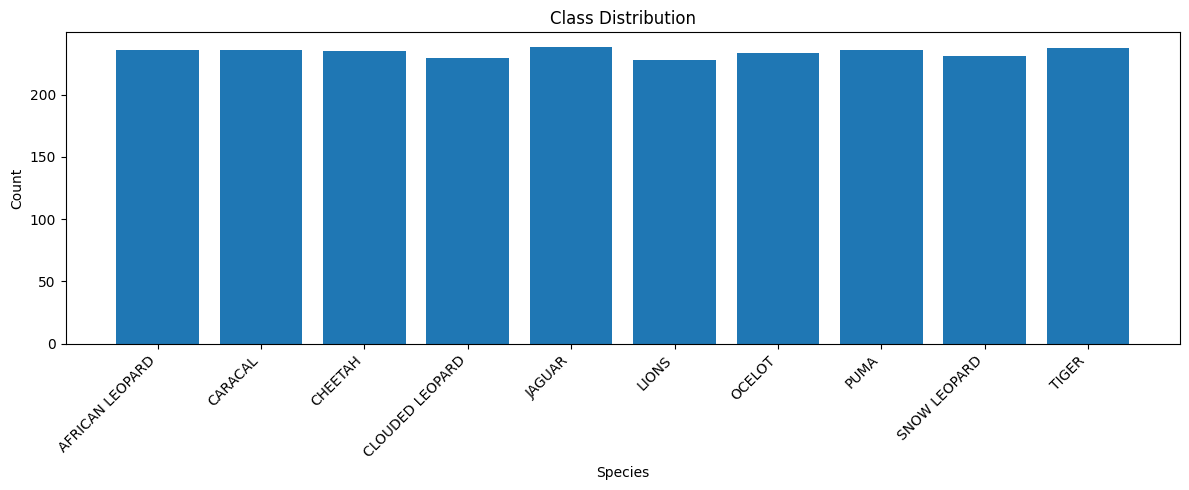

AFRICAN LEOPARD     :  236
CARACAL             :  236
CHEETAH             :  235
CLOUDED LEOPARD     :  229
JAGUAR              :  238
LIONS               :  228
OCELOT              :  233
PUMA                :  236
SNOW LEOPARD        :  231
TIGER               :  237


In [5]:
# Class distribution
labels = [label for _, label in temp_ds]
counts = Counter(labels)

plt.figure(figsize=(12, 5))
classes = [temp_ds.get_class(i) for i in sorted(counts.keys())]
class_counts = [counts[i] for i in sorted(counts.keys())]

plt.bar(classes, class_counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

for c, cnt in zip(classes, class_counts):
    print(f"{c:20s}: {cnt:4d}")

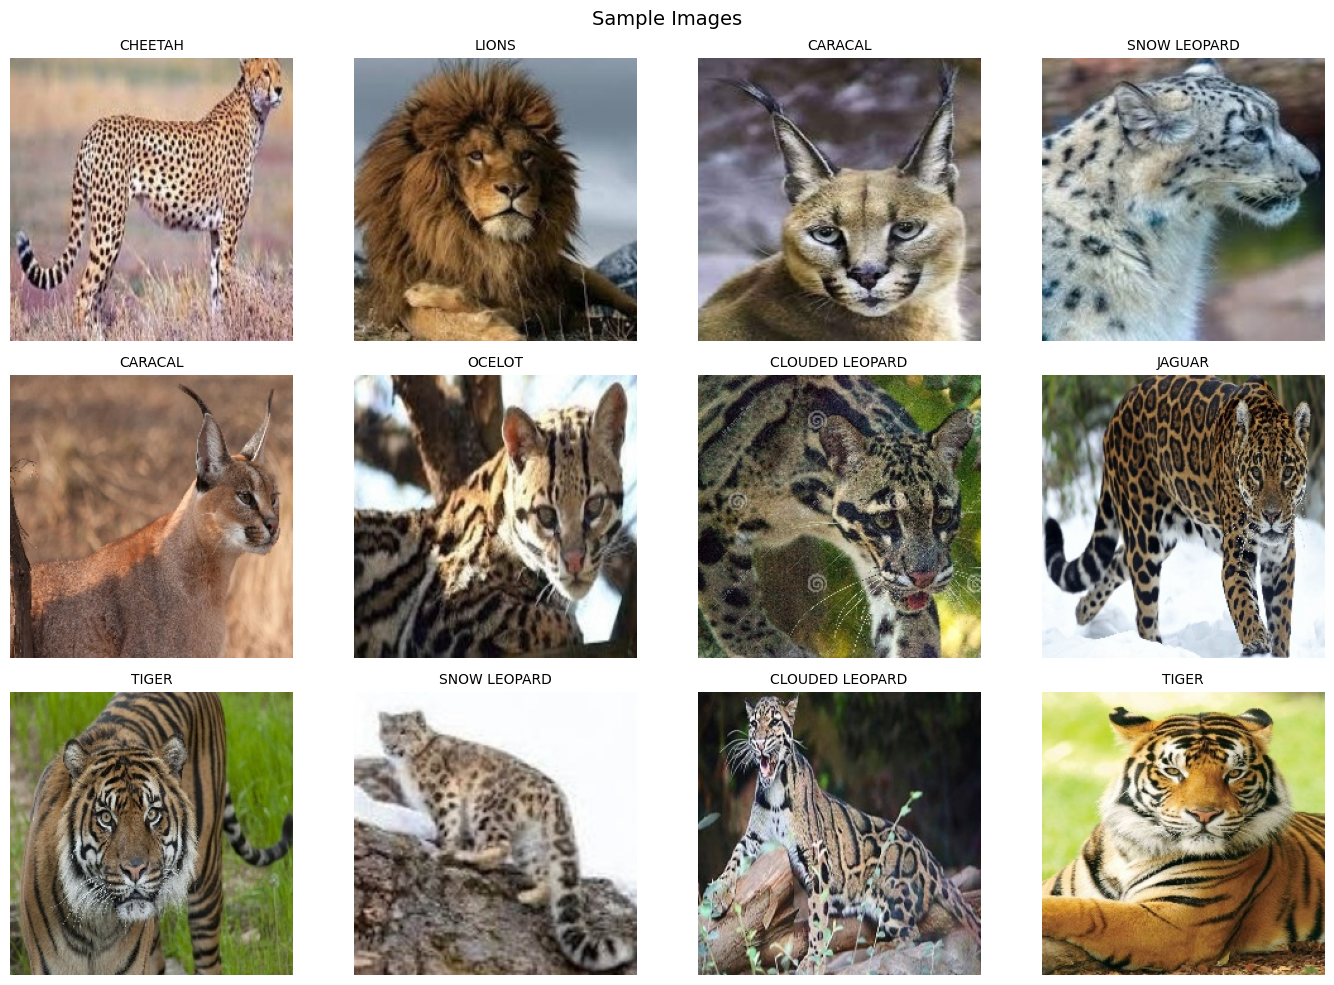

In [6]:
# Sample images
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

indices = np.random.choice(len(temp_ds), 12, replace=False)

for idx, ax in zip(indices, axes):
    img, label = temp_ds[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(temp_ds.get_class(label), fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [7]:
# Transforms
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Datasets
train_ds = BigCatDataset(train_path, transform=train_transform)
val_ds = BigCatDataset(val_path, transform=test_transform)
test_ds = BigCatDataset(test_path, transform=test_transform)

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 74
Val batches: 2
Test batches: 2


In [8]:
import torchvision.transforms as transforms

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# IMPROVED TRAINING TRANSFORM with aggressive augmentation
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),

    # Geometric augmentations
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),  # More rotation
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Random shifts
        scale=(0.9, 1.1),       # Random zoom
        shear=10                # Random shear
    ),

    # Color augmentations
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    # Add blur sometimes (helps with overfitting)
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
    ], p=0.3),

    # Random erasing (randomly hide parts of image)
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

# TEST TRANSFORM stays simple (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("✓ Strong augmentation defined")
print("  - Rotation up to ±25°")
print("  - Random shifts, zoom, shear")
print("  - Color jittering")
print("  - Gaussian blur (30% chance)")
print("  - Random erasing (20% chance)")

✓ Strong augmentation defined
  - Rotation up to ±25°
  - Random shifts, zoom, shear
  - Color jittering
  - Gaussian blur (30% chance)
  - Random erasing (20% chance)


## Model Setup

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BigCatCNN(num_classes=len(train_ds.classes)).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Parameters: {total_params:,}")
print(f"\n{model}")

Device: cuda
Parameters: 4,823,626

BigCatCNN(
  (conv1a): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1a): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1b): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2a): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2b): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3a): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3a): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3b): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3b): BatchNorm2d(256,

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

## Training Functions

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (batch_idx + 1) % 20 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}] '
                  f'Loss: {loss.item():.4f} Acc: {100.*correct/total:.2f}%')
    
    return running_loss / len(loader), 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

## Train Model

In [12]:
set_seed(42)  # Reset before training

num_epochs = 35
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("="*60)
print("TRAINING")
print("="*60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nTrain: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
    print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print("★ Best model saved")

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

TRAINING

Epoch 1/35
------------------------------------------------------------
  Batch [20/74] Loss: 1.8617 Acc: 22.97%
  Batch [40/74] Loss: 1.8033 Acc: 25.86%
  Batch [60/74] Loss: 1.9303 Acc: 29.22%

Train: Loss=1.8619, Acc=30.44%
Val:   Loss=3.0787, Acc=22.00%
★ Best model saved

Epoch 2/35
------------------------------------------------------------
  Batch [20/74] Loss: 1.6043 Acc: 36.41%
  Batch [40/74] Loss: 1.5739 Acc: 37.19%
  Batch [60/74] Loss: 1.6785 Acc: 39.06%

Train: Loss=1.6007, Acc=39.63%
Val:   Loss=1.4404, Acc=46.00%
★ Best model saved

Epoch 3/35
------------------------------------------------------------
  Batch [20/74] Loss: 1.5134 Acc: 47.03%
  Batch [40/74] Loss: 1.1760 Acc: 45.31%
  Batch [60/74] Loss: 1.0472 Acc: 47.29%

Train: Loss=1.3374, Acc=48.48%
Val:   Loss=1.4531, Acc=36.00%

Epoch 4/35
------------------------------------------------------------
  Batch [20/74] Loss: 1.5121 Acc: 53.28%
  Batch [40/74] Loss: 1.3625 Acc: 54.14%
  Batch [60/74] Loss:

## Plot Training History

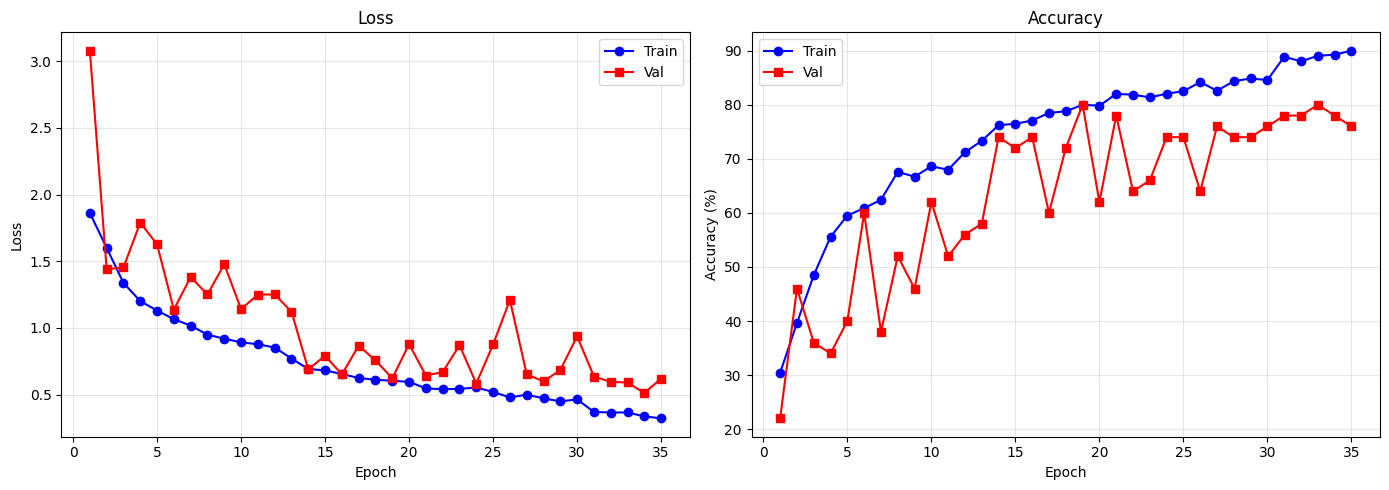

Final Train Acc: 90.00%
Final Val Acc: 76.00%
Best Val Acc: 80.00%


In [13]:
epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-s', label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'], 'r-s', label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"Final Val Acc: {history['val_acc'][-1]:.2f}%")
print(f"Best Val Acc: {max(history['val_acc']):.2f}%")

## Test Set Evaluation

In [15]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
class_correct = {i: 0 for i in range(len(test_ds.classes))}
class_total = {i: 0 for i in range(len(test_ds.classes))}

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        for i in range(len(labels)):
            label = labels[i].item()
            class_total[label] += 1
            if predicted[i] == labels[i]:
                class_correct[label] += 1

test_acc = 100. * correct / total

print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"\nTest Accuracy: {test_acc:.2f}% ({correct}/{total})\n")

print("Per-Class Accuracy:")
print("-" * 60)
for i in sorted(class_total.keys()):
    if class_total[i] > 0:
        acc = 100. * class_correct[i] / class_total[i]
        print(f"{test_ds.get_class(i):20s}: {acc:6.2f}% ({class_correct[i]}/{class_total[i]})")
print("="*60)

TEST SET RESULTS

Test Accuracy: 76.00% (38/50)

Per-Class Accuracy:
------------------------------------------------------------
AFRICAN LEOPARD     :  80.00% (4/5)
CARACAL             :  80.00% (4/5)
CHEETAH             : 100.00% (5/5)
CLOUDED LEOPARD     : 100.00% (5/5)
JAGUAR              :  60.00% (3/5)
LIONS               :  40.00% (2/5)
OCELOT              :  40.00% (2/5)
PUMA                : 100.00% (5/5)
SNOW LEOPARD        :  60.00% (3/5)
TIGER               : 100.00% (5/5)


## Model Statistics

In [16]:
total_params = sum(p.numel() for p in model.parameters())

print("="*60)
print("MODEL EFFICIENCY")
print("="*60)
print(f"Parameters: {total_params:,}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"\nEfficiency: {test_acc / (total_params / 1000):.4f}")
print("(accuracy per 1K parameters)")
print("="*60)

print("\nGrading:")
print(f"  EDA: 5 points")
print(f"  Accuracy: {'15 pts (≥77%)' if test_acc >= 77 else '10 pts (≥70%)' if test_acc >= 70 else '<10 pts'}")
print(f"  Competitive: 10 points (efficiency-based)")

MODEL EFFICIENCY
Parameters: 4,823,626
Test Accuracy: 76.00%

Efficiency: 0.0158
(accuracy per 1K parameters)

Grading:
  EDA: 5 points
  Accuracy: 10 pts (≥70%)
  Competitive: 10 points (efficiency-based)


## Save for Submission

In [17]:
# Save weights
with open('big_cat_model.pkl', 'wb') as f:
    pickle.dump(model.state_dict(), f)

print("Model saved!")
print("\nSubmission files:")
print("  1. big_cat_model.py")
print("  2. big_cat_model.pkl")
print("  3. big_cat_classifier_clean.ipynb")

Model saved!

Submission files:
  1. big_cat_model.py
  2. big_cat_model.pkl
  3. big_cat_classifier_clean.ipynb


## Visualize Predictions

In [ ]:
images, labels = next(iter(test_loader))
images, labels = images[:12], labels[:12]

with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = outputs.max(1)

# Denormalize
mean_t = torch.tensor(mean).view(3, 1, 1)
std_t = torch.tensor(std).view(3, 1, 1)
images = images * std_t + mean_t
images = torch.clamp(images, 0, 1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for idx in range(12):
    img = images[idx].permute(1, 2, 0).numpy()
    true = test_ds.get_class(labels[idx].item())
    pred = test_ds.get_class(predicted[idx].item())
    
    axes[idx].imshow(img)
    color = 'green' if labels[idx] == predicted[idx] else 'red'
    axes[idx].set_title(f"True: {true}\nPred: {pred}", color=color, fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()